In [1]:
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"


<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height:1.7; color:#2c3e50;">

  <!-- Title -->
  <h1 style="text-align:center; color:#1e88e5;">
    🩺 Comprehensive Skin Lesion Classification & Analysis
  </h1>

  <!-- Intro Card -->
  <div style="background:#f5f9ff; border-left:6px solid #1e88e5; padding:16px; border-radius:8px; margin-bottom:20px;">
    <p style="font-size:15px;">
      Welcome to this <b>advanced Skin Lesion Classification Project</b>!  
      This project presents a complete workflow for analyzing, visualizing, and classifying skin lesion images using 
      <span style="color:#1565c0;"><b>state-of-the-art Machine Learning and Deep Learning techniques</b></span>.
    </p>
    <p style="font-size:15px;">
      The primary goal is to assist <b>dermatologists and medical professionals</b> in accurately identifying various skin lesion types,
      improving diagnostic efficiency, and enabling <b>early detection of malignant conditions</b>.
    </p>
  </div>

  <!-- Objectives -->
  <h2 style="color:#2e7d32;">🎯 Project Objectives</h2>
  <ul style="list-style:none; padding-left:0;">
    <li>📊 <b>Comprehensive dataset analysis</b> including class distribution, patient age, gender, and lesion localization.</li>
    <li>🖼️ <b>Image preprocessing & visualization</b> with automatic and informative descriptions.</li>
    <li>🔬 <b>Clinical risk stratification</b> for benign, precancerous, and malignant lesions.</li>
    <li>🤖 <b>High-performance predictive models</b> for multi-class skin lesion classification.</li>
    <li>📈 <b>Professional & interactive visualizations</b> for insight extraction and decision-making.</li>
    <li>💡 <b>End-to-end pipeline</b> from data exploration to medical image classification.</li>
  </ul>

  <!-- Highlights -->
  <h2 style="color:#6a1b9a;"> Key Highlights</h2>

<table style="width:100%; border-spacing:12px;">
  <tr>
    <td style="background:#f3e5f5; padding:14px; border-radius:8px; width:50%;">
      🔹 Thousands of labeled skin lesion images with rich patient metadata.
    </td>
    <td style="background:#e8f5e9; padding:14px; border-radius:8px; width:50%;">
      🔹 Advanced visualizations using <b>Matplotlib</b> & <b>Seaborn</b>.
    </td>
  </tr>

  <tr>
    <td style="background:#e3f2fd; padding:14px; border-radius:8px;">
      🔹 Sample image grids with clear labels and automatic descriptions.
    </td>
    <td style="background:#fff3e0; padding:14px; border-radius:8px;">
      🔹 Robust preprocessing: missing data handling, normalization, and cleaning.
    </td>
  </tr>

  <tr>
    <td style="background:#ede7f6; padding:14px; border-radius:8px;">
      🔹 Strong ML & DL models for accurate multi-class classification.
    </td>
    <td style="background:#fce4ec; padding:14px; border-radius:8px;">
      🔹 Publication-ready plots suitable for research and presentations.
    </td>
  </tr>
</table>


  <!-- Footer -->
  <div style="margin-top:25px; text-align:center; font-size:14px; color:#555;">
    🚀 Designed for <b>medical AI research</b>, <b>clinical insight</b>, and <b>real-world impact</b>.
  </div>

</div>

## 🧬 Skin Lesion Classes

> **Legend of skin lesion abbreviations used in this project**

---

### 🟢 **Benign Lesions**
- 🟩 **nv** — *Melanocytic Nevus*
- 🟩 **bkl** — *Benign Keratosis*
- 🟩 **df** — *Dermatofibroma*
- 🟩 **vasc** — *Vascular Lesion*

---

### 🟡 **Pre-cancerous Lesion**
- 🟨 **akiec** — *Actinic Keratoses*

---

### 🔴 **Malignant Lesions**
- 🟥 **bcc** — *Basal Cell Carcinoma*
- 🟥 **mel** — *Melanoma*

---


<h2 style="
  text-align:center;
  color:#0d47a1;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Import Libraries
</h2>

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

2026-05-08 23:52:49.760318: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778284369.997240      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778284370.073555      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778284370.651756      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778284370.651873      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778284370.651877      16 computation_placer.cc:177] computation placer alr

<h2 style="
  text-align:center;
  color:#0d47a1;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Load Metadata
</h2>

In [3]:
DATA_DIR = '/kaggle/input/skin-cancer-mnist-ham10000'
IMAGE_DIR = os.path.join(DATA_DIR, 'HAM10000_images')
META_PATH = os.path.join(DATA_DIR, 'HAM10000_metadata.csv')
df = pd.read_csv(META_PATH)
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


<h2 style="
  text-align:center;
  color:#0d47a1;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Comprehensive Data Analysis Wıth Visualızations
</h2>

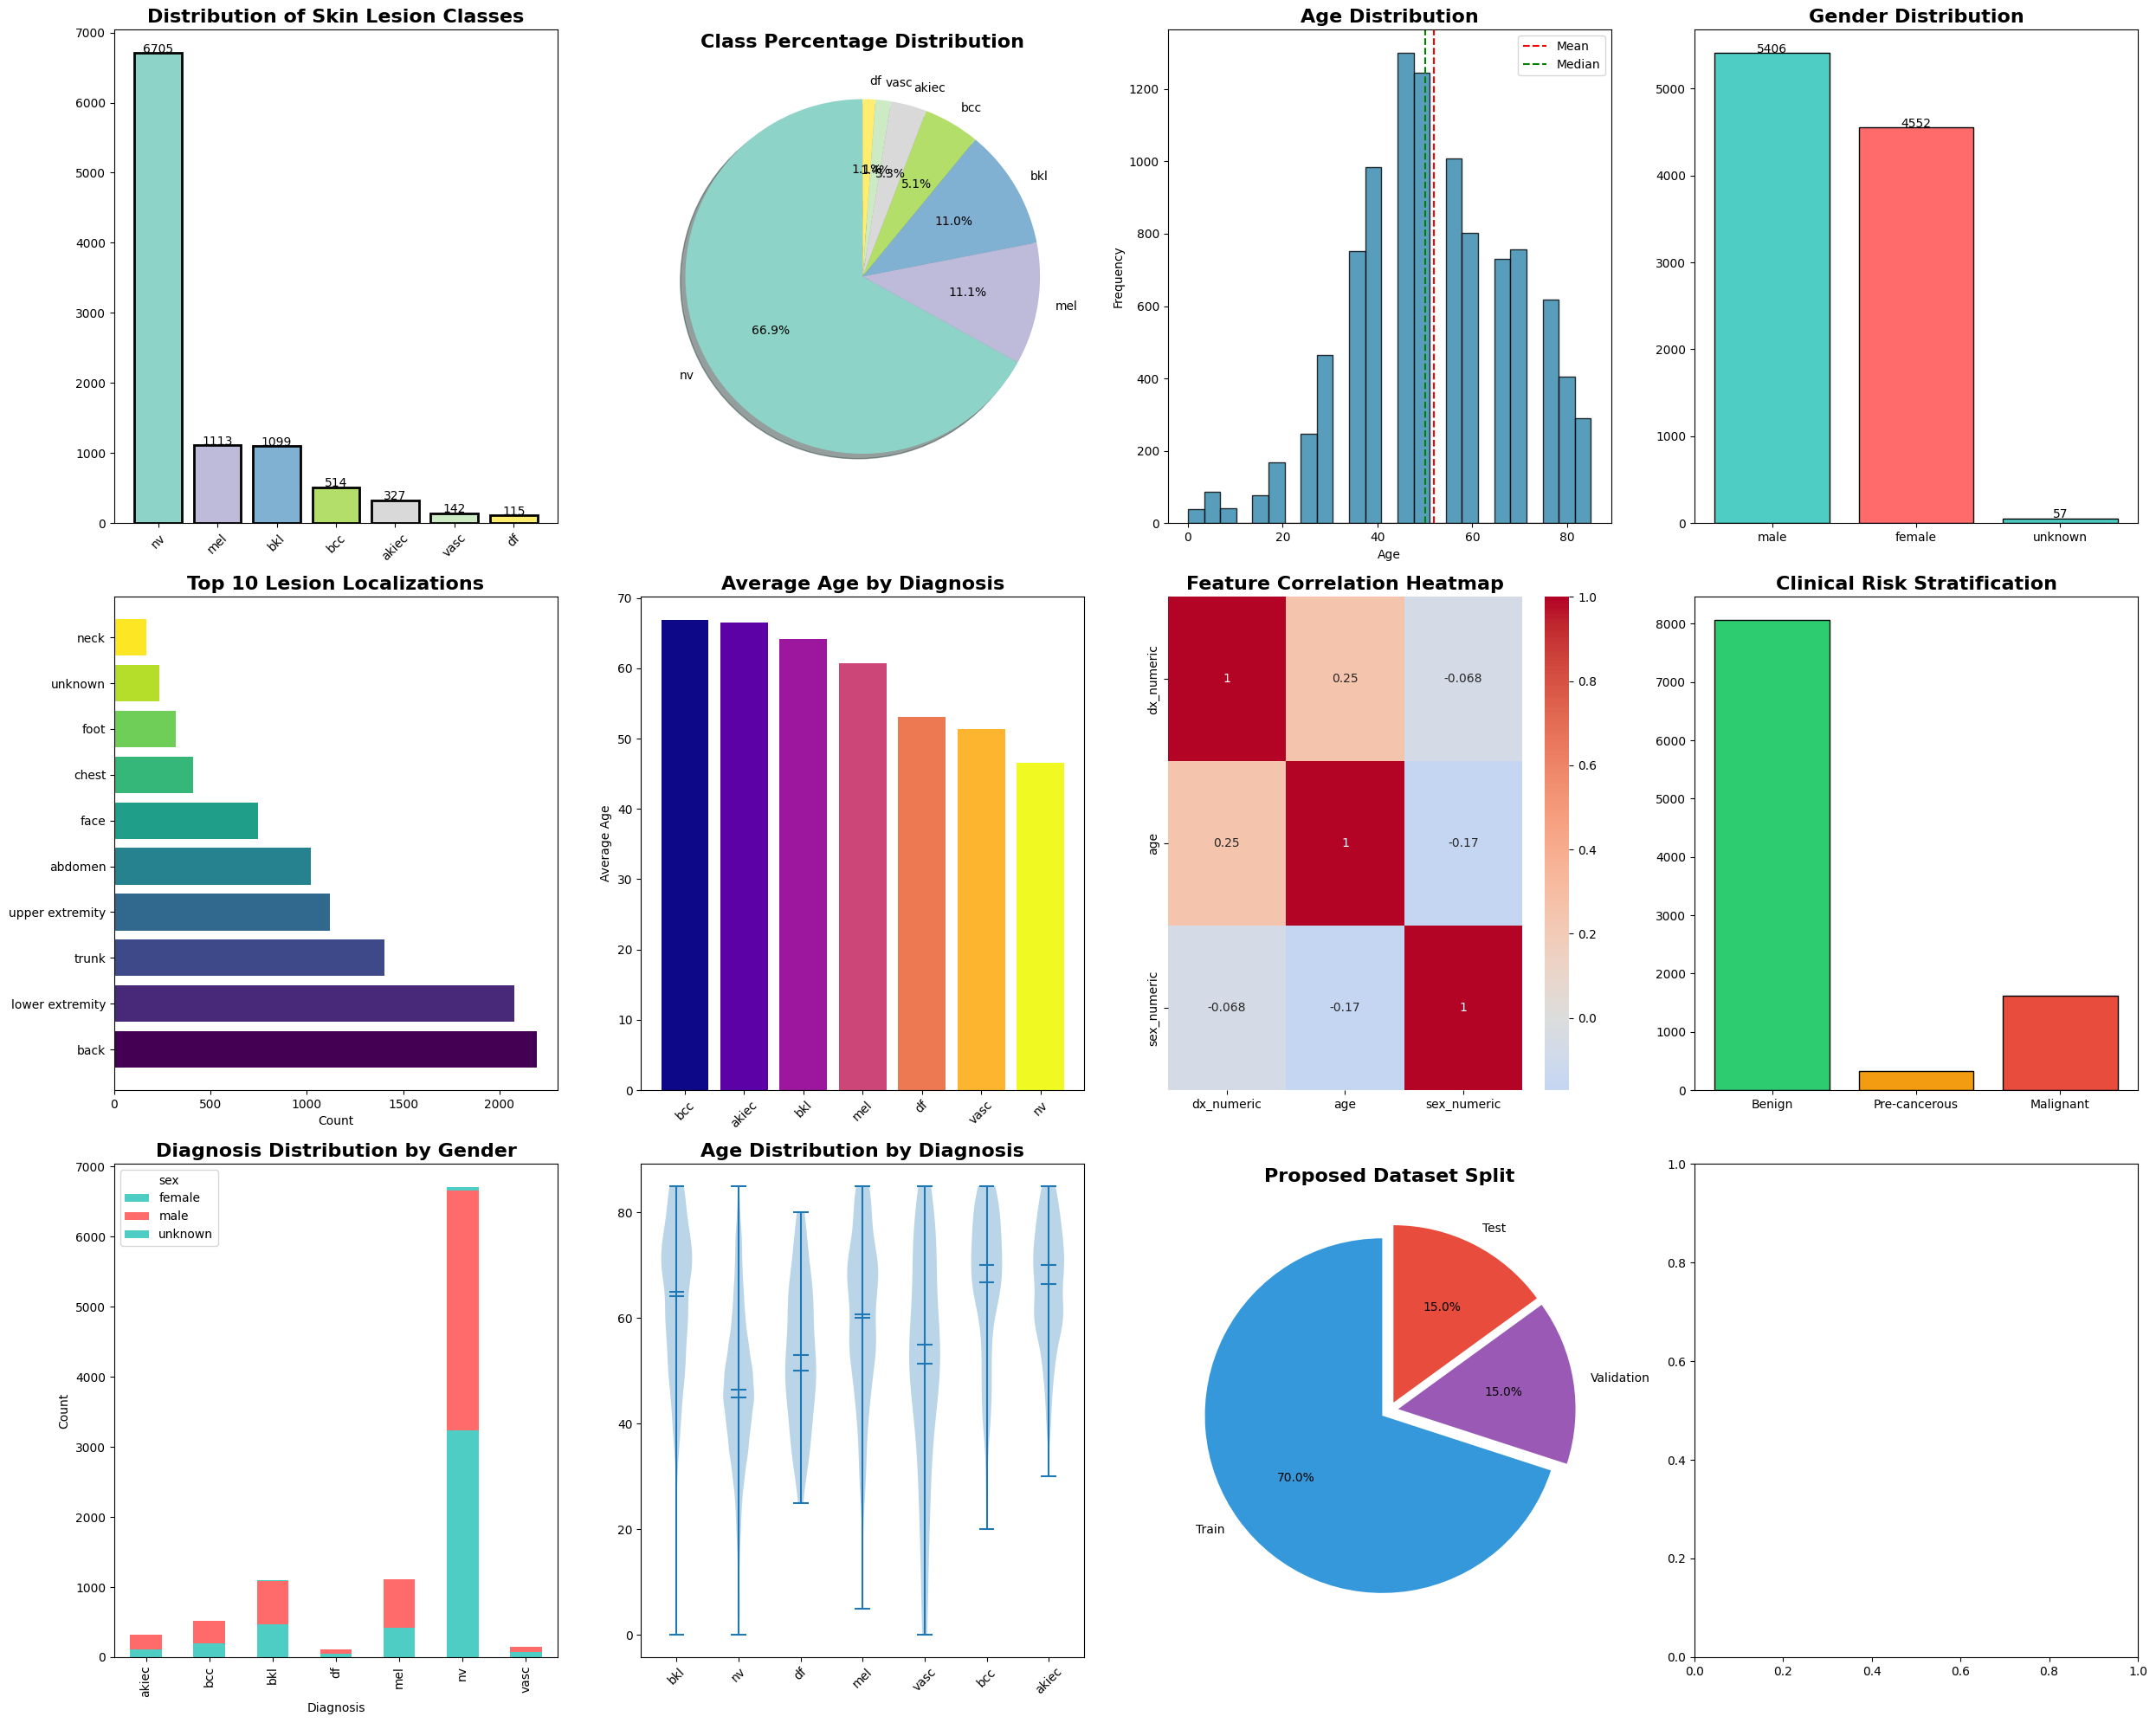

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os


df_metadata = df.copy()  

numeric_cols = ['age']
df_metadata = df_metadata.dropna(subset=['dx'])
df_metadata['age'] = df_metadata['age'].fillna(df_metadata['age'].median())
df_metadata['sex'] = df_metadata['sex'].fillna('unknown')
df_metadata['localization'] = df_metadata['localization'].fillna('unknown')

class_to_num = {cls: idx for idx, cls in enumerate(df_metadata['dx'].unique())}
class_dict = class_to_num.copy()

fig = plt.figure(figsize=(25, 20))

# 1. Class Distribution
plt.subplot(3, 4, 1)
class_counts = df_metadata['dx'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(class_counts)))
bars = plt.bar(range(len(class_counts)), class_counts.values, color=colors, edgecolor='black', linewidth=2)
plt.title('Distribution of Skin Lesion Classes', fontsize=16, fontweight='bold')
plt.xticks(range(len(class_counts)), class_counts.index, rotation=45)
for bar, value in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{value}', ha='center')

# 2. Pie Chart
plt.subplot(3, 4, 2)
plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=90, colors=colors, shadow=True)
plt.title('Class Percentage Distribution', fontsize=16, fontweight='bold')

# 3. Age Distribution
plt.subplot(3, 4, 3)
plt.hist(df_metadata['age'], bins=25, color='#2E86AB', edgecolor='black', alpha=0.8)
plt.title('Age Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.axvline(df_metadata['age'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df_metadata['age'].median(), color='green', linestyle='--', label='Median')
plt.legend()

# 4. Gender Distribution
plt.subplot(3, 4, 4)
gender_counts = df_metadata['sex'].value_counts()
bars = plt.bar(gender_counts.index, gender_counts.values, color=['#4ECDC4', '#FF6B6B'], edgecolor='black')
plt.title('Gender Distribution', fontsize=16, fontweight='bold')
for bar, value in zip(bars, gender_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{value}', ha='center')

# 5. Localization Distribution
plt.subplot(3, 4, 5)
local_counts = df_metadata['localization'].value_counts().head(10)
y_pos = np.arange(len(local_counts))
plt.barh(y_pos, local_counts.values, color=plt.cm.viridis(np.linspace(0, 1, len(local_counts))))
plt.yticks(y_pos, local_counts.index)
plt.xlabel('Count')
plt.title('Top 10 Lesion Localizations', fontsize=16, fontweight='bold')

# 6. Average Age by Diagnosis
plt.subplot(3, 4, 6)
age_by_dx = df_metadata.groupby('dx')['age'].mean().sort_values(ascending=False)
plt.bar(range(len(age_by_dx)), age_by_dx.values, color=plt.cm.plasma(np.linspace(0, 1, len(age_by_dx))))
plt.title('Average Age by Diagnosis', fontsize=16, fontweight='bold')
plt.xticks(range(len(age_by_dx)), age_by_dx.index, rotation=45)
plt.ylabel('Average Age')

# 7. Heatmap of Feature Correlation
plt.subplot(3, 4, 7)
numeric_df = df_metadata.copy()
numeric_df['dx_numeric'] = numeric_df['dx'].map(class_to_num)
numeric_df['sex_numeric'] = numeric_df['sex'].map({'male':0, 'female':1})
corr_matrix = numeric_df[['dx_numeric','age','sex_numeric']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')

# 8. Risk Stratification
plt.subplot(3, 4, 8)
risk_categories = ['Benign', 'Pre-cancerous', 'Malignant']
benign_cases = len(df_metadata[df_metadata['dx'].isin(['nv','bkl','df','vasc'])])
precancerous_cases = len(df_metadata[df_metadata['dx']=='akiec'])
malignant_cases = len(df_metadata[df_metadata['dx'].isin(['bcc','mel'])])
risk_counts = [benign_cases, precancerous_cases, malignant_cases]
plt.bar(risk_categories, risk_counts, color=['#2ECC71','#F39C12','#E74C3C'], edgecolor='black')
plt.title('Clinical Risk Stratification', fontsize=16, fontweight='bold')

# 9. Stacked Bar: Gender vs Diagnosis
plt.subplot(3, 4, 9)
pivot_table = pd.crosstab(df_metadata['dx'], df_metadata['sex'])
pivot_table.plot(kind='bar', stacked=True, color=['#4ECDC4','#FF6B6B'], ax=plt.gca())
plt.title('Diagnosis Distribution by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Diagnosis')
plt.ylabel('Count')

# 10. Violin Plot of Age by Diagnosis
plt.subplot(3, 4, 10)
data_for_violin = [df_metadata[df_metadata['dx']==cls]['age'].values for cls in df_metadata['dx'].unique()]
plt.violinplot(data_for_violin, showmeans=True, showmedians=True)
plt.title('Age Distribution by Diagnosis', fontsize=16, fontweight='bold')
plt.xticks(range(1,len(df_metadata['dx'].unique())+1), df_metadata['dx'].unique(), rotation=45)

# 11. Dataset Split Visualization
plt.subplot(3, 4, 11)
sizes = [70,15,15]
labels = ['Train','Validation','Test']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#3498DB','#9B59B6','#E74C3C'], startangle=90, explode=[0.05,0.05,0.05])
plt.title('Proposed Dataset Split', fontsize=16, fontweight='bold')

# 12. Sample Images Grid with Auto Descriptions
plt.subplot(3, 4, 12)
sample_imgs = []
for idx, row in df_metadata.sample(4).iterrows():
    img_path = os.path.join('HAM10000_images', row['image_id']+'.jpg')
    if os.path.exists(img_path):
        img = plt.imread(img_path)
        sample_imgs.append((img, row['dx']))

for i, (img, label) in enumerate(sample_imgs):
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Sample Lesion\nClass: {label}', fontsize=12)

plt.tight_layout()
plt.show()

<h2 style="
  text-align:center;
  color:#0d47a1;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Image Loading & Preprocessing 
</h2>

In [5]:
IMG_SIZE = 64


images = []
labels = []

# Image folders
image_dirs = [
    '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1',
    '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2'
]

image_path_dict = {}

for img_dir in image_dirs:
    for img_name in os.listdir(img_dir):
        image_path_dict[img_name.split('.')[0]] = os.path.join(img_dir, img_name)

for _, row in df.iterrows():
    img_id = row['image_id']
    img_path = image_path_dict.get(img_id)

    if img_path is None:
        continue

    img = cv2.imread(img_path)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    images.append(img)
    labels.append(row['dx'])

images = np.array(images, dtype='float32') / 255.0
labels = np.array(labels)

<h2 style="
  text-align:center;
  color:#0d47a1;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
    Label Encoding
</h2

In [6]:
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

le.classes_

array(['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'], dtype='<U5')

<h2 style="
  text-align:center;
  color:#0d47a1;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Train / Test Split
</h2>

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels_encoded,
    test_size=0.2,
    random_state=42,
    stratify=labels_encoded
)

<h2 style="
  text-align:center;
  color:#0d47a1;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Preparing Data for Classical Machine Learning
</h2>

In [8]:
# Flatten images for classical ML models

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened Train Shape:", X_train_flat.shape)
print("Flattened Test Shape:", X_test_flat.shape)

Flattened Train Shape: (8012, 12288)
Flattened Test Shape: (2003, 12288)


<h2 style="
  text-align:center;
  color:#1565c0;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  K-Nearest Neighbors (KNN) Classifier
</h2>

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_flat, y_train)

y_pred_knn = knn.predict(X_test_flat)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.6979530703944083
              precision    recall  f1-score   support

           0       0.47      0.22      0.29        65
           1       0.38      0.34      0.36       103
           2       0.36      0.30      0.33       220
           3       0.33      0.13      0.19        23
           4       0.33      0.08      0.12       223
           5       0.77      0.94      0.85      1341
           6       0.25      0.04      0.06        28

    accuracy                           0.70      2003
   macro avg       0.41      0.29      0.31      2003
weighted avg       0.64      0.70      0.65      2003



<h2 style="
  text-align:center;
  color:#ad1457;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  KNN From Scratch Implementation
</h2>

In [10]:
import numpy as np
from collections import Counter

class KNN_FromScratch:

    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)

    def _predict(self, x):

        distances = [
            self.euclidean_distance(x, x_train)
            for x_train in self.X_train
        ]

        k_indices = np.argsort(distances)[:self.k]

        k_nearest_labels = [
            self.y_train[i]
            for i in k_indices
        ]

        most_common = Counter(k_nearest_labels).most_common(1)

        return most_common[0][0]


# Train model
knn_scratch = KNN_FromScratch(k=5)

# Smaller subset for faster execution
X_train_small = X_train_flat[:1000]
y_train_small = y_train[:1000]

X_test_small = X_test_flat[:200]
y_test_small = y_test[:200]

knn_scratch.fit(X_train_small, y_train_small)

y_pred_scratch = knn_scratch.predict(X_test_small)

scratch_accuracy = accuracy_score(
    y_test_small,
    y_pred_scratch
)

print("KNN From Scratch Accuracy:", scratch_accuracy)

KNN From Scratch Accuracy: 0.605


<h2 style="
  text-align:center;
  color:#2e7d32;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Support Vector Machine (SVM) Classifier
</h2>

In [11]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')

svm.fit(X_train_flat, y_train)

y_pred_svm = svm.predict(X_test_flat)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7174238642036944
              precision    recall  f1-score   support

           0       0.38      0.09      0.15        65
           1       0.62      0.34      0.44       103
           2       0.47      0.27      0.34       220
           3       0.00      0.00      0.00        23
           4       0.59      0.12      0.20       223
           5       0.75      0.98      0.85      1341
           6       0.00      0.00      0.00        28

    accuracy                           0.72      2003
   macro avg       0.40      0.26      0.28      2003
weighted avg       0.66      0.72      0.65      2003



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<h2 style="
  text-align:center;
  color:#ef6c00;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Decision Tree Classifier
</h2>

In [12]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_flat, y_train)

y_pred_dt = dt.predict(X_test_flat)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6260609086370444
              precision    recall  f1-score   support

           0       0.18      0.15      0.17        65
           1       0.30      0.24      0.27       103
           2       0.27      0.30      0.29       220
           3       0.04      0.04      0.04        23
           4       0.29      0.30      0.29       223
           5       0.81      0.81      0.81      1341
           6       0.12      0.11      0.11        28

    accuracy                           0.63      2003
   macro avg       0.29      0.28      0.28      2003
weighted avg       0.63      0.63      0.63      2003



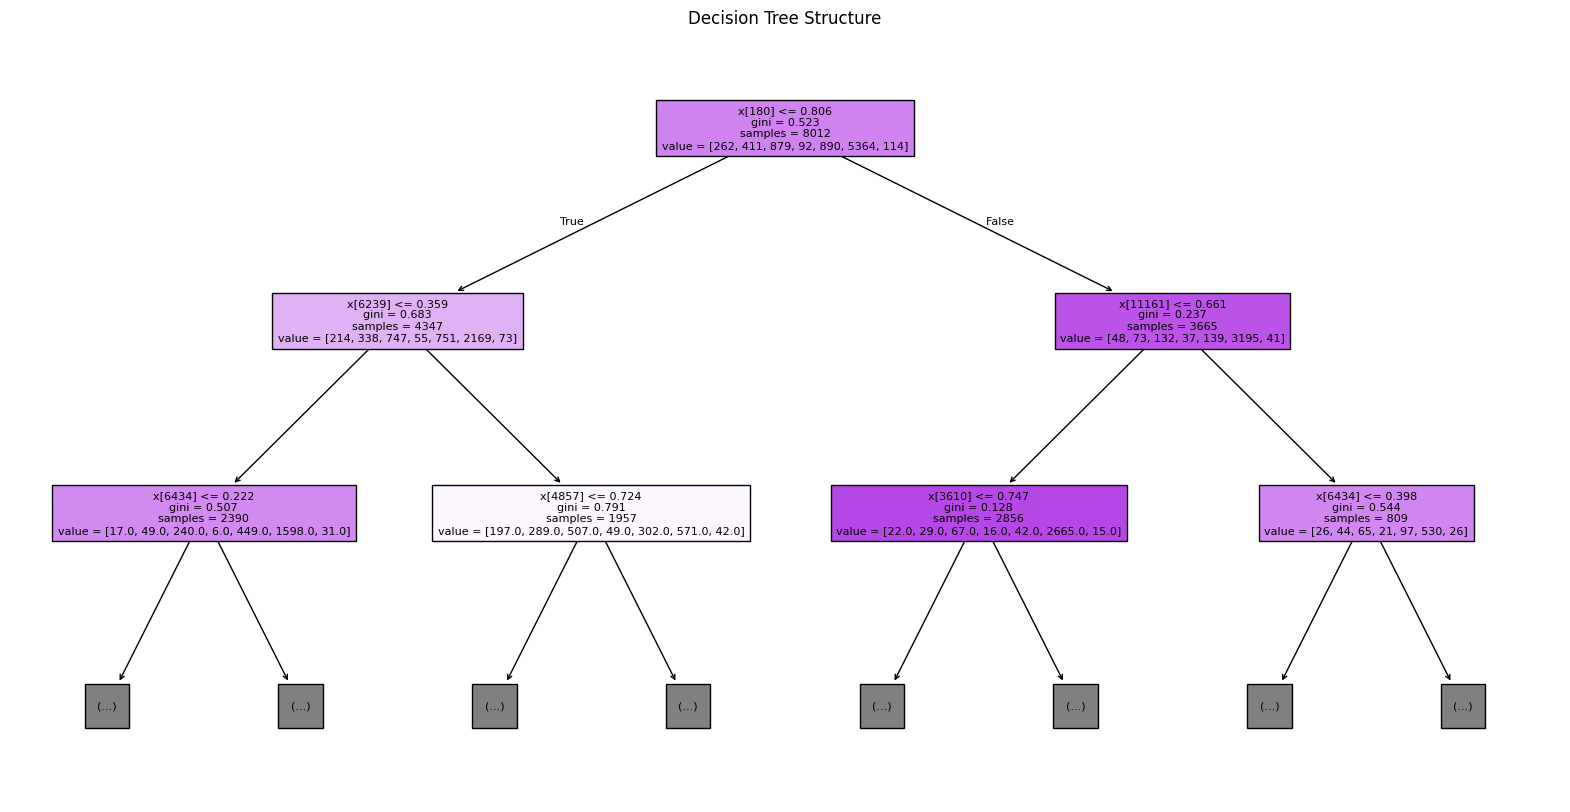

In [13]:
from sklearn import tree

plt.figure(figsize=(20,10))

tree.plot_tree(
    dt,
    filled=True,
    max_depth=2,
    fontsize=8
)

plt.title("Decision Tree Structure")

plt.show()

<h2 style="
  text-align:center;
  color:#6a1b9a;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Random Forest Classifier
</h2>

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_flat, y_train)

y_pred_rf = rf.predict(X_test_flat)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7179231153270095
              precision    recall  f1-score   support

           0       0.50      0.11      0.18        65
           1       0.54      0.37      0.44       103
           2       0.43      0.32      0.36       220
           3       0.00      0.00      0.00        23
           4       0.45      0.14      0.21       223
           5       0.77      0.96      0.85      1341
           6       0.00      0.00      0.00        28

    accuracy                           0.72      2003
   macro avg       0.38      0.27      0.29      2003
weighted avg       0.65      0.72      0.66      2003



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<h2 style="
  text-align:center;
  color:#00838f;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Model Performance Comparison
</h2>

In [15]:
results = {
    "Model": [
        "KNN",
        "SVM",
        "Decision Tree",
        "Random Forest"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy
0,KNN,0.697953
1,SVM,0.717424
2,Decision Tree,0.626061
3,Random Forest,0.717923


<h2 style="
  text-align:center;
  color:#c62828;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Accuracy Comparison Visualization
</h2>

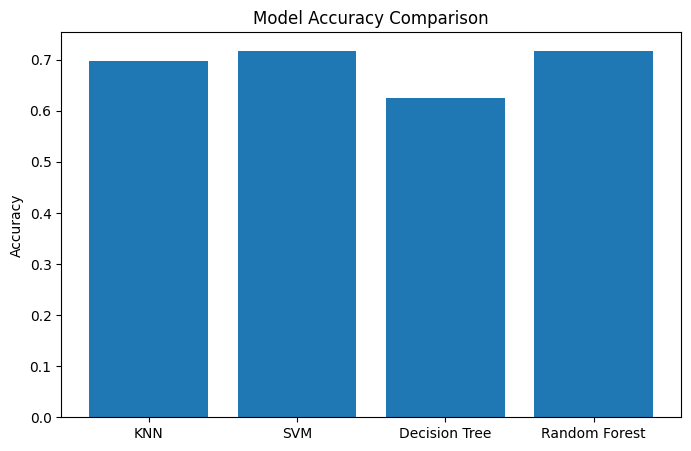

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

<h2 style="
  text-align:center;
  color:#4527a0;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Hyperparameter Tuning using GridSearchCV
</h2>

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train_flat, y_train)

print("Best Parameters:", grid.best_params_)

print("Best Accuracy:", grid.best_score_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Best Accuracy: 0.7099351662163217


<h2 style="
  text-align:center;
  color:#0d47a1;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  CNN Model Architecture
</h2>

In [18]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-09 00:13:56.145445: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,275,847 (4.87 MB)

 Trainable params: 1,275,399 (4.87 MB)

 Non-trainable params: 448 (1.75 KB)

<h2 style="
  text-align:center;
  color:#0d47a1;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Model Training
</h2>

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=25,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/25
226/226 ━━━━━━━━━━━━━━━━━━━━ 40s 156ms/step - accuracy: 0.6096 - loss: 1.3329 - val_accuracy: 0.0486 - val_loss: 2.6202
Epoch 2/25
226/226 ━━━━━━━━━━━━━━━━━━━━ 35s 153ms/step - accuracy: 0.7073 - loss: 0.8066 - val_accuracy: 0.6459 - val_loss: 1.0856
Epoch 3/25
226/226 ━━━━━━━━━━━━━━━━━━━━ 35s 155ms/step - accuracy: 0.7315 - loss: 0.7355 - val_accuracy: 0.7481 - val_loss: 0.6889
Epoch 4/25
226/226 ━━━━━━━━━━━━━━━━━━━━ 35s 155ms/step - accuracy: 0.7623 - loss: 0.6514 - val_accuracy: 0.7618 - val_loss: 0.6729
Epoch 5/25
226/226 ━━━━━━━━━━━━━━━━━━━━ 35s 155ms/step - accuracy: 0.7717 - loss: 0.6153 - val_accuracy: 0.7569 - val_loss: 0.6757
Epoch 6/25
226/226 ━━━━━━━━━━━━━━━━━━━━ 35s 155ms/step - accuracy: 0.7937 - loss: 0.5481 - val_accuracy: 0.7569 - val_loss: 0.6778
Epoch 7/25
226/226 ━━━━━━━━━━━━━━━━━━━━ 35s 155ms/step - accuracy: 0.8101 - loss: 0.5278 - val_accuracy: 0.7494 - val_loss: 0.6995
Epoch 8/25
226/226 ━━━━━━━━━━━━━━━━━━━━ 41s 155ms/step - accuracy: 0.8244 - loss: 0

<h2 style="
  text-align:center;
  color:#0d47a1;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Accuracy Curve
</h2>

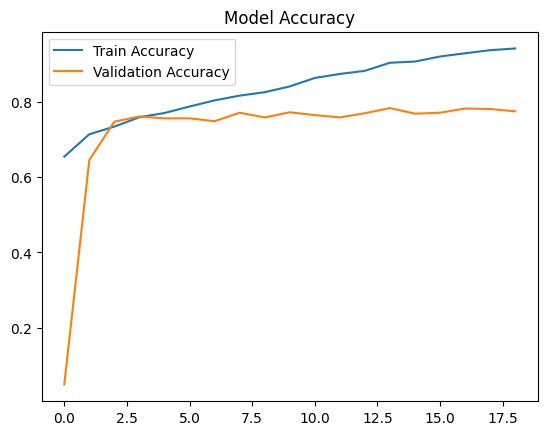

In [20]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

<h2 style="
  text-align:center;
  color:#0d47a1;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Loss Curve
</h2>

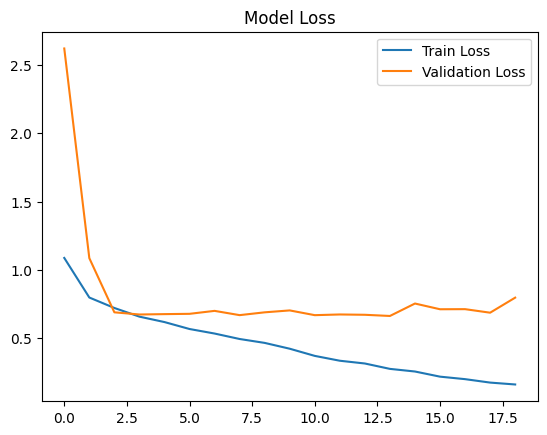

In [21]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

<h2 style="
  text-align:center;
  color:#0d47a1;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Model Evaluation
</h2>

In [22]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
              precision    recall  f1-score   support

       akiec       0.45      0.55      0.50        65
         bcc       0.68      0.50      0.57       103
         bkl       0.57      0.47      0.52       220
          df       0.75      0.13      0.22        23
         mel       0.51      0.43      0.46       223
          nv       0.86      0.93      0.89      1341
        vasc       0.80      0.43      0.56        28

    accuracy                           0.77      2003
   macro avg       0.66      0.49      0.53      2003
weighted avg       0.76      0.77      0.76      2003



<h2 style="
  text-align:center;
  color:#1b5e20;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
Final Comparison Between Classical ML Models and CNN
</h2>


In [23]:
cnn_accuracy = accuracy_score(y_test, y_pred)

results_df.loc[len(results_df)] = ["CNN", cnn_accuracy]

results_df

,Model,Accuracy
0,KNN,0.697953
1,SVM,0.717424
2,Decision Tree,0.626061
3,Random Forest,0.717923
4,CNN,0.773340


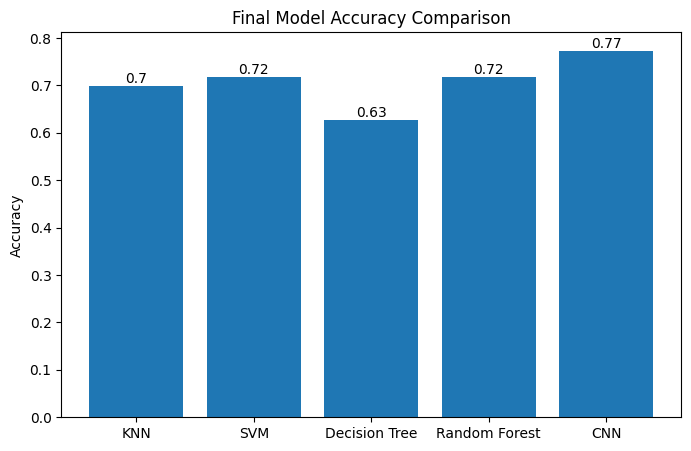

In [24]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

for bar in bars:
    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        round(yval, 2),
        ha='center',
        va='bottom'
    )

plt.title("Final Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

<h2 style="
  text-align:center;
  color:#0d47a1;
  font-weight:700;
  font-size:32px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Confusion Matrix Analysis
</h2>


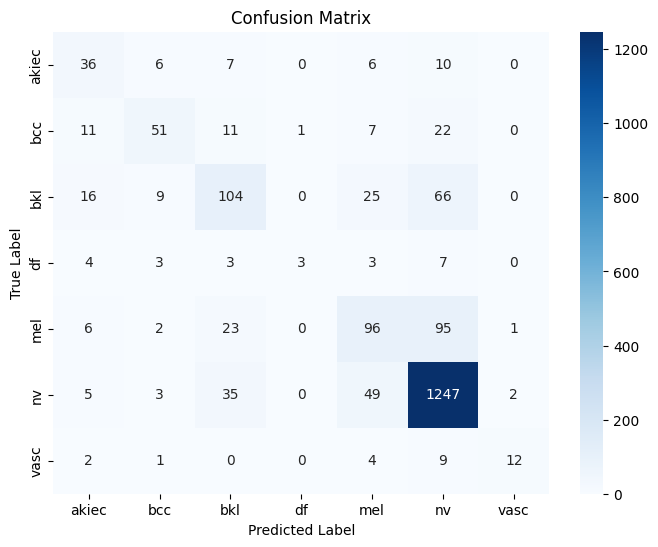

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


<h2 style="
  text-align:center;
  color:#6a1b9a;
  font-weight:700;
  font-size:32px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Top-3 Prediction Analysis
</h2>


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step
True Label: nv
Top 1: nv (1.00)
Top 2: mel (0.00)
Top 3: akiec (0.00)


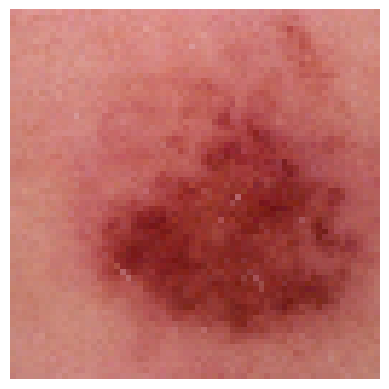

In [26]:
# Top-3 predictions for test images
y_pred_probs = model.predict(X_test)

def show_top3_predictions(index):
    probs = y_pred_probs[index]
    top3_idx = np.argsort(probs)[-3:][::-1]

    print("True Label:", le.classes_[y_test[index]])
    for i, idx in enumerate(top3_idx, 1):
        print(f"Top {i}: {le.classes_[idx]} ({probs[idx]:.2f})")

    img = (X_test[index] * 255).astype(np.uint8)
    plt.imshow(img)
    plt.axis("off")
    plt.show()


# مثال
show_top3_predictions(10)


<h2 style="
  text-align:center;
  color:#0d47a1;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Model Saving
</h2>


In [27]:
# Save trained model
MODEL_PATH = "skin_cancer_ham10000_cnn.keras"
model.save(MODEL_PATH)

print(f"✅ Model saved successfully as {MODEL_PATH}")


✅ Model saved successfully as skin_cancer_ham10000_cnn.keras


<h2 style="
  text-align:center;
  color:#0d47a1;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Function
</h2>

In [28]:
def draw_circle_prediction(image, label):
    img = image.copy()
    h, w, _ = img.shape
    center = (w // 2, h // 2)
    radius = min(center) - 10

    cv2.circle(img, center, radius, (255, 0, 0), 3)

    plt.figure()
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')


<h2 style="
  text-align:center;
  color:#0d47a1;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Random prediction visualization on Sample 
</h2>

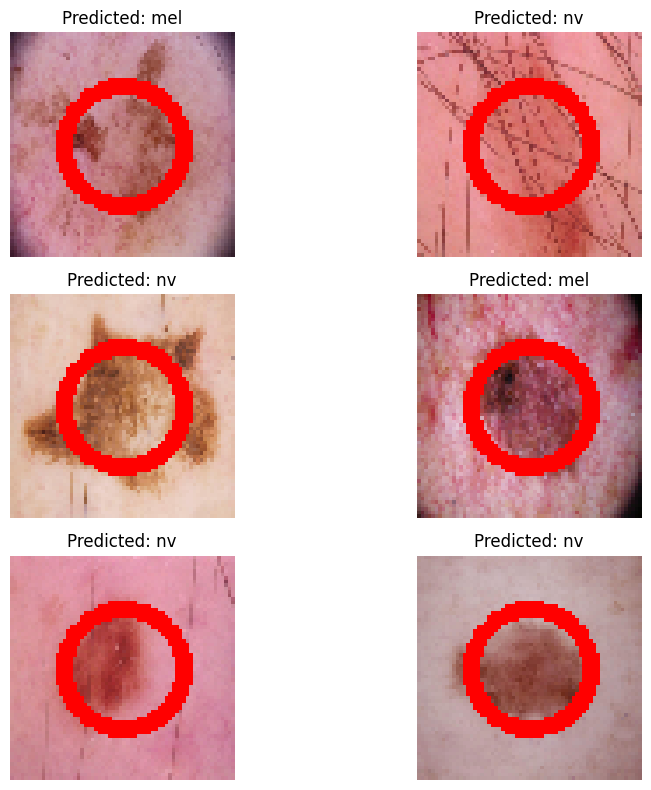

In [29]:
num_samples = 6 

plt.figure(figsize=(10, 8))

for i in range(num_samples):
    idx = np.random.randint(0, len(X_test))
    img = (X_test[idx] * 255).astype(np.uint8)
    pred_label = le.classes_[y_pred[idx]]

    img_copy = img.copy()
    h, w, _ = img_copy.shape
    center = (w // 2, h // 2)
    radius = min(center) - 15
    cv2.circle(img_copy, center, radius, (255, 0, 0), 3)

    plt.subplot(num_samples // 2, 2, i + 1)
    plt.imshow(img_copy)
    plt.title(f'Predicted: {pred_label}')
    plt.axis('off')

plt.tight_layout()
plt.show()

<h2 style="
  text-align:center;
  color:#0d47a1;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Interactive Skin Lesion Gallery with Enhanced Images & Professional Explanations

</h2>


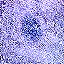
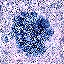
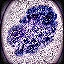
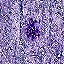
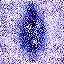
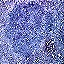
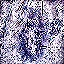
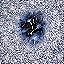
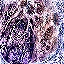

In [30]:
from IPython.display import display, HTML
import base64
import cv2
import numpy as np

def image_to_base64(img):
    _, buffer = cv2.imencode('.jpg', img)
    return base64.b64encode(buffer).decode()

def enhance_image(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    enhanced = cv2.merge((cl,a,b))
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)

    kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
    sharp = cv2.filter2D(enhanced, -1, kernel)

    return sharp

descriptions = {
    'mel': "Malignant Melanoma detected. This is a high-risk skin cancer that may spread rapidly. Early diagnosis significantly improves survival rates.",
    'bcc': "Basal Cell Carcinoma predicted. A common form of skin cancer with moderate clinical risk and high treatability.",
    'akiec': "Actinic Keratosis identified. A pre-cancerous lesion caused by long-term sun exposure and requires monitoring.",
    'bkl': "Benign Keratosis detected. A non-cancerous skin lesion with no immediate medical concern.",
    'nv': "Melanocytic Nevus (mole). This is a benign lesion and generally considered low risk.",
    'df': "Dermatofibroma detected. A benign fibrous skin lesion that is clinically harmless.",
    'vasc': "Vascular lesion identified. A benign abnormality related to blood vessels."
}

html = """
<style>
.gallery {
    display: grid;
    grid-template-columns: repeat(3, 1fr);
    gap: 24px;
    font-family: Arial, sans-serif;
}
.card {
    border-radius: 14px;
    padding: 14px;
    background: #ffffff;
    box-shadow: 0 8px 20px rgba(0,0,0,0.12);
}
.card img {
    width: 100%;
    border-radius: 12px;
    border: 3px solid rgba(255,0,0,0.35);
}
.title {
    font-weight: bold;
    margin-top: 10px;
    font-size: 15px;
}
.desc {
    font-size: 13px;
    color: #333;
    margin-top: 6px;
    line-height: 1.4;
}
</style>
<div class="gallery">
"""

num_images = 9

for _ in range(num_images):
    idx = np.random.randint(0, len(X_test))
    img = (X_test[idx] * 255).astype(np.uint8)
    pred_label = le.classes_[y_pred[idx]]

    img = enhance_image(img)
    img_base64 = image_to_base64(img)

    html += f"""
    <div class="card">
        <img src="data:image/jpeg;base64,{img_base64}">
        <div class="title">Predicted Class: {pred_label}</div>
        <div class="desc">{descriptions[pred_label]}</div>
    </div>
    """

html += "</div>"

display(HTML(html))

<h2 style="
  text-align:center;
  color:#1b5e20;
  font-weight:700;
  font-size:33px;
  text-shadow: 2px 2px 6px rgba(0,0,0,0.25);
">
  Saving and Converting Model  
  <br>
  <span style="font-size:18px; font-weight:400;">
    
  </span>
</h2>


In [31]:
import tensorflow as tf
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open(
    "/kaggle/working/skin_cancer_ham10000_cnn.tflite",
    "wb"
) as f:

    f.write(tflite_model)

print("✅ TFLite model saved")

INFO:tensorflow:Assets written to: /tmp/tmp26eykc9m/assets


INFO:tensorflow:Assets written to: /tmp/tmp26eykc9m/assets


Saved artifact at '/tmp/tmp26eykc9m'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  137906646742800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906646743952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906642880464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906642878736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906642878928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906725711376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906642880272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906642881232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906642881040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906642879120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906642880848:

W0000 00:00:1778286341.534024      16 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778286341.534166      16 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1778286341.547695      16 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


In [32]:
import tensorflow as tf
from IPython.display import FileLink

# Save TFLite model
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

tflite_path = "/kaggle/working/skin_cancer_ham10000_cnn.tflite"

with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print("✅ TFLite model saved")


# Save labels
labels_path = "/kaggle/working/label_classes.txt"

with open(labels_path, "w") as f:
    for label in le.classes_:
        f.write(label + "\n")

print("✅ Labels file saved")


# Download links
print("\nDownload Model:")
display(FileLink(tflite_path))

print("\nDownload Labels:")
display(FileLink(labels_path))

INFO:tensorflow:Assets written to: /tmp/tmpp9a09e9y/assets


INFO:tensorflow:Assets written to: /tmp/tmpp9a09e9y/assets


Saved artifact at '/tmp/tmpp9a09e9y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  137906646742800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906646743952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906642880464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906642878736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906642878928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906725711376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906642880272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906642881232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906642881040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906642879120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137906642880848:

W0000 00:00:1778286345.035699      16 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778286345.035741      16 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


/kaggle/working/skin_cancer_ham10000_cnn.tflite


Download Labels:


/kaggle/working/label_classes.txt